In [1]:
#Installing the necessary libraries
%pip install pandas joblib scikit-learn


Note: you may need to restart the kernel to use updated packages.


# Data importation and preprocessing
We use `pandas` to import the dataset into our notebook and and start the preprocessing phase

## 2.1 Data Acquisition

**Dataset:** Heart Failure Prediction dataset (UCI / Kaggle "Heart Failure Prediction Dataset"), combining five independent heart-disease datasets into a single 918-record file.

**Why this dataset fits the assignment domain:** cardiovascular disease is the leading cause of death globally, and a model that flags high-risk patients from routine clinical measurements (age, blood pressure, cholesterol, ECG results, exercise response) supports earlier, cheaper intervention than diagnostic testing alone. This directly satisfies Assignment requirement 1(ii) — explaining the importance and impact of the problem.

**Features:**
| Column | Description | Type |
|---|---|---|
| Age | Patient age in years | Numeric |
| Sex | M / F | Categorical (nominal) |
| ChestPainType | TA, ATA, NAP, ASY | Categorical (nominal) |
| RestingBP | Resting blood pressure (mm Hg) | Numeric |
| Cholesterol | Serum cholesterol (mm/dl) | Numeric |
| FastingBS | Fasting blood sugar > 120 mg/dl (1/0) | Categorical (binary) |
| RestingECG | Normal, ST, LVH | Categorical (nominal) |
| MaxHR | Maximum heart rate achieved | Numeric |
| ExerciseAngina | Exercise-induced angina (Y/N) | Categorical (binary) |
| Oldpeak | ST depression induced by exercise | Numeric |
| ST_Slope | Up, Flat, Down | Categorical (nominal) |
| HeartDisease | Target: 1 = disease, 0 = no disease | Categorical (binary, target) |

The cell below loads the CSV into a pandas DataFrame for exploration.


In [2]:
import pandas as pd
import joblib

data = pd.read_csv("../datasets/heart_dataset.csv")

data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 2.2 Initial Data Exploration & Statistical Summary

Before cleaning anything, we inspect the dataset's structure, data types, and summary statistics. This satisfies the "provide visualization and statistical summaries" part of Assignment requirement 2(ii). Specifically we check:
- **Shape** — number of records and features
- **Columns** — feature names
- **Info** — data types and non-null counts per column
- **Missing values** — any nulls that need handling
- **Duplicate rows** — any exact duplicate records
- **Describe** — mean, std, min/max, and quartiles for numeric features


In [3]:
data.shape

(918, 12)

In [4]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Inspecting categorical values

`data.describe()` only summarizes numeric columns, so we separately check the unique values of each categorical column. This confirms there are no inconsistent labels (e.g. typos, mixed casing) before encoding, and tells us how many categories each feature has.


In [10]:
data["Sex"].unique()

array(['M', 'F'], dtype=object)

In [11]:
data["ChestPainType"].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [12]:
data["RestingECG"].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

In [13]:
data["ExerciseAngina"].unique()

array(['N', 'Y'], dtype=object)

In [14]:
data["ST_Slope"].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

### Confirming no duplicates before moving to cleaning

Re-checking for duplicates here confirms the dataset is still duplicate-free after the categorical inspection above (no rows were altered), before we move on to handling invalid values.


In [15]:
data.duplicated().sum()

np.int64(0)

## 2.3 Data Cleaning: Handling Disguised Missing Values

`data.isnull().sum()` reported no missing values, but that doesn't mean the data is clean — in this dataset, missing `RestingBP` and `Cholesterol` readings were recorded as **0** rather than `NaN`. A resting blood pressure or cholesterol level of 0 is not physiologically possible, so these are effectively missing values disguised as zeros. We identify and quantify them before deciding how to handle them.


In [16]:
data[(data["RestingBP"] == 0) | (data["Cholesterol"] == 0)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


In [17]:
print("RestingBP = 0:", (data["RestingBP"] == 0).sum())
print("Cholesterol = 0:", (data["Cholesterol"] == 0).sum())

RestingBP = 0: 1
Cholesterol = 0: 172


We impute these disguised-missing values with the **median** of each column rather than the mean, since median is more robust to outliers and skew in clinical measurements, and rather than dropping rows, since that would shrink an already-small dataset (918 records).


In [18]:
data["RestingBP"] = data["RestingBP"].replace(0, data["RestingBP"].median())

data["Cholesterol"] = data["Cholesterol"].replace(0, data["Cholesterol"].median())

In [19]:
data.shape

(918, 12)

## 2.4 Encoding Categorical Variables

Machine learning algorithms in Scikit-learn require numeric input, so the categorical columns (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`) must be converted to numeric form. We first check `dtypes` to confirm which columns are still non-numeric (`object`), then encode them.

**Note on encoding choice:** `Sex` and `ExerciseAngina` are binary, so label encoding (0/1) is safe. `ChestPainType`, `RestingECG`, and `ST_Slope` have no natural order between categories, so label-encoding them assigns an arbitrary ranking (e.g. ATA=0, ASY=1, NAP=2) that some models (e.g. logistic regression) could misread as ordinal. This is flagged here as a known limitation to revisit in the modeling notebook — one-hot encoding is the safer alternative for those three columns.


In [20]:
data.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    data[column] = encoder.fit_transform(data[column])
    label_encoders[column] = encoder

data.head()

for name, encoder in label_encoders.items():
    print(name, encoder.classes_)


Sex ['F' 'M']
ChestPainType ['ASY' 'ATA' 'NAP' 'TA']
RestingECG ['LVH' 'Normal' 'ST']
ExerciseAngina ['N' 'Y']
ST_Slope ['Down' 'Flat' 'Up']


## 2.5 Exploratory Data Analysis & Visualization

With the data cleaned and encoded, we visualize it to understand feature distributions and relationships with the target variable. This satisfies the visualization requirement in Assignment 2(ii) and informs model/feature choices in the next notebook (Model Selection and Training).


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

**Target distribution** — checks whether `HeartDisease` is balanced or imbalanced, which determines whether accuracy alone is a reliable evaluation metric later (an imbalanced target would call for F1-score/precision-recall instead).


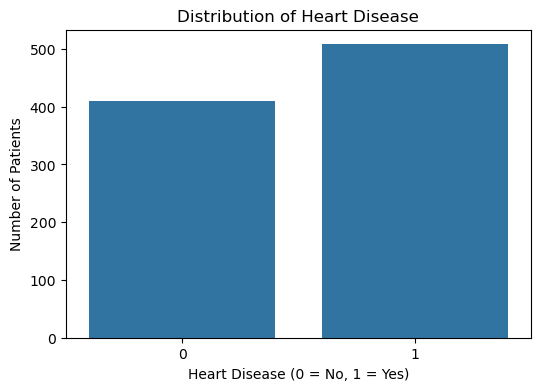

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="HeartDisease", data=data)

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

**Age distribution** — shows the age range and concentration of patients in the sample.


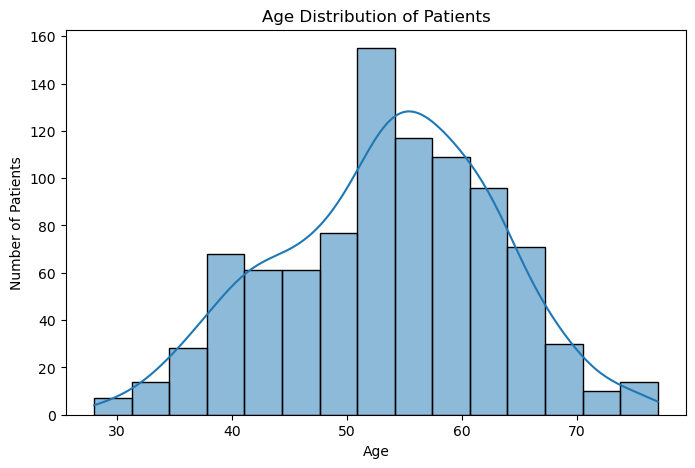

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(data["Age"], bins=15, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

**Correlation heatmap** — highlights which features are most linearly related to `HeartDisease` and to each other (useful for spotting multicollinearity before modeling).


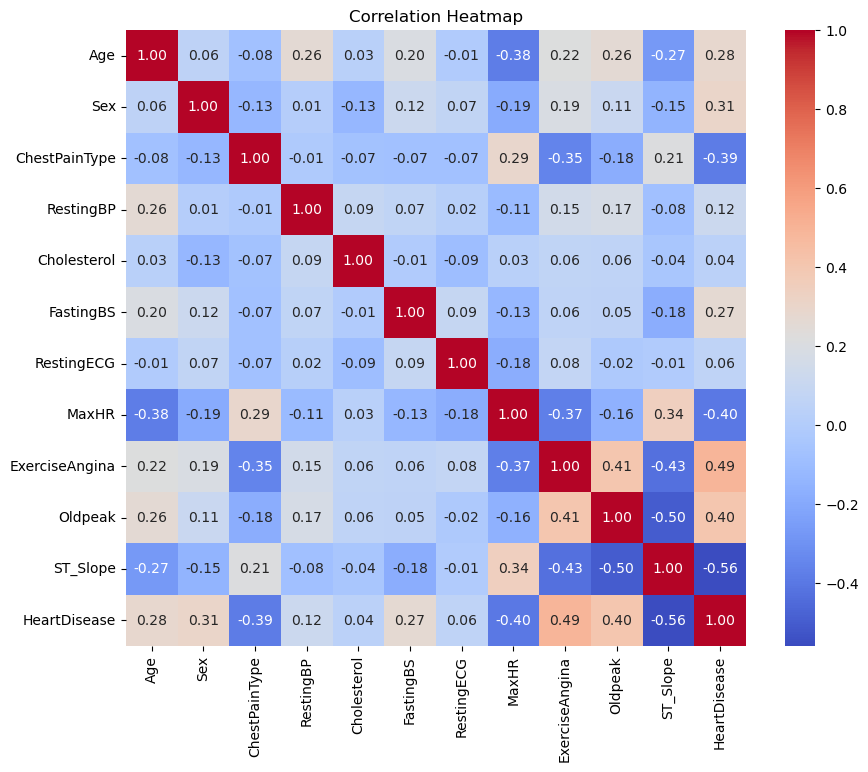

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

**Heart disease by sex** — checks whether disease prevalence differs by sex in this sample.


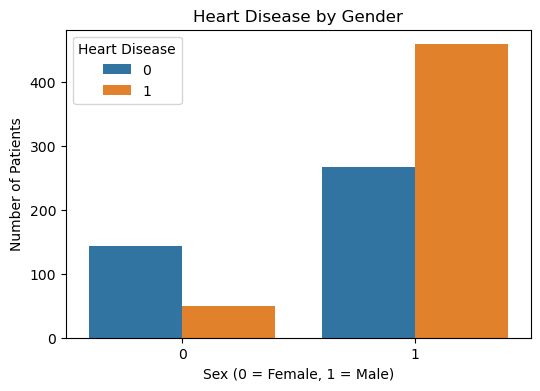

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", hue="HeartDisease", data=data)

plt.title("Heart Disease by Gender")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Number of Patients")

plt.legend(title="Heart Disease")

plt.show()

**Age vs. maximum heart rate** — max heart rate typically declines with age; this plot checks whether that relationship holds here and whether it separates disease/no-disease cases.


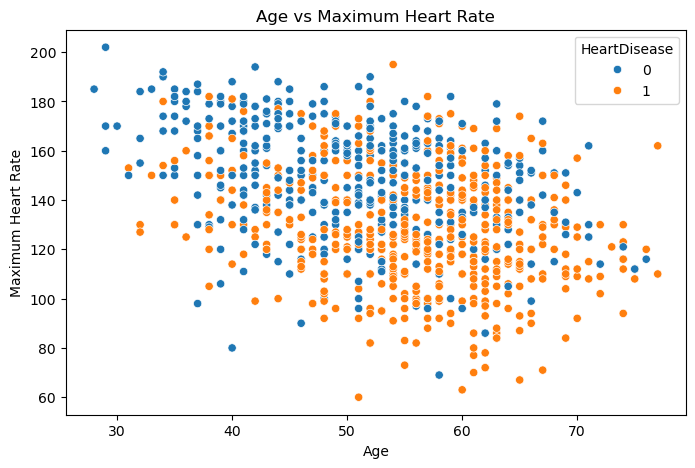

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Age", y="MaxHR", hue="HeartDisease", data=data)

plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")

plt.show()

**Chest pain type distribution** — shows how patients are spread across the four chest pain categories.


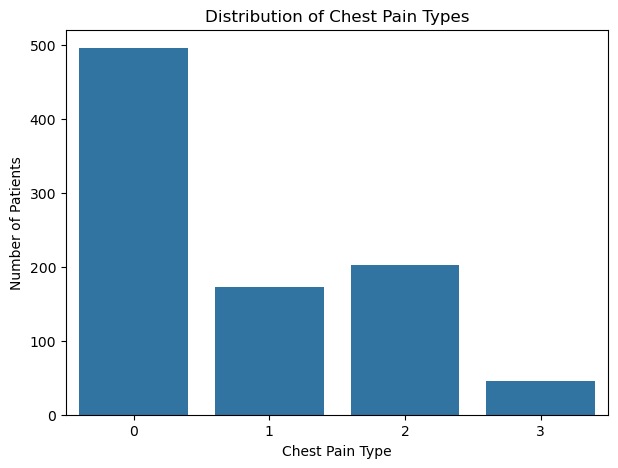

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(x="ChestPainType", data=data)

plt.title("Distribution of Chest Pain Types")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.show()

## 2.6 Validation

A final check confirms the zero-value imputation from Section 2.3 worked as expected — both counts should now read 0.


In [29]:
print("RestingBP = 0:", (data["RestingBP"] == 0).sum())
print("Cholesterol = 0:", (data["Cholesterol"] == 0).sum())

RestingBP = 0: 0
Cholesterol = 0: 0


# Traing the Model

In [30]:
%pip install joblib scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Preparing the Features and Target

Before training a machine learning model, we need to separate the dataset into:

- **Features (`X`)** – the input variables the model will use to make predictions.
- **Target (`y`)** – the value the model is trying to predict.

In this project:

- `X` contains all patient information such as age, cholesterol level, blood pressure, chest pain type, and other medical measurements.
- `y` contains the **HeartDisease** column, where:
  - `0` = No heart disease
  - `1` = Heart disease

The model learns patterns from the features to predict the target.

## Splitting the Dataset into Training and Testing Sets

Machine learning models should be evaluated on data they have never seen before.

To achieve this, the dataset is divided into two parts:

- **Training set (80%)**
  - Used for learning patterns from the data.
- **Testing set (20%)**
  - Used to evaluate how well the trained model performs on unseen data.

This helps estimate how the model will perform in real-world situations.

In [31]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

X = data.drop("HeartDisease", axis=1)
y = data["HeartDisease"]
feature_order = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

# training using the random forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluating Training Accuracy

After training the Random Forest classifier, a **sanity check** is performed by measuring its accuracy on the training dataset. The model first predicts the labels for the training data using `rf.predict(X_train)`, and these predictions are compared with the true labels (`y_train`) using `accuracy_score()`. The resulting value, stored in `rf_train_acc`, represents the proportion of training samples that were classified correctly. Printing this value provides an initial indication of how well the model has learned from the training data. However, training accuracy alone is not sufficient to judge model performance, as a model with very high training accuracy may still perform poorly on unseen data due to overfitting. Therefore, the next step is to evaluate the model using the testing dataset.

In [32]:
# Sanity check for accuracy
rf_train_acc = accuracy_score(y_train, rf.predict(X_train))

print(f"Random Forest training accuracy: {rf_train_acc:.3f}")

Random Forest training accuracy: 1.000


## Saving the Trained Model

After training the Random Forest classifier, the model is saved to disk using the `joblib` library. Saving the model allows it to be reused without retraining, which saves time and computational resources. The statement `joblib.dump(rf, "random_forest_model.joblib")` serializes the trained model (`rf`) and stores it in a file named **`random_forest_model.joblib`**. This file can later be loaded with `joblib.load()` to make predictions, evaluate performance, or integrate the model into an application, ensuring that the same trained model is used consistently across different sessions.

In [33]:
# Saving the model for the evaluation section
joblib.dump(rf, "../Backend/ml_artifacts/random_forest_model.joblib")
joblib.dump(label_encoders, "../Backend/ml_artifacts/label_encoders.joblib")
joblib.dump(feature_order, "../Backend/ml_artifacts/feature_order.joblib")

['../Backend/ml_artifacts/feature_order.joblib']

## 4. Evaluate and Fine-Tune

We test the Random Forest model on the held-out test set (data it has never seen) and assess performance using accuracy and F1-score, as specified in the assignment. We then fine-tune its hyperparameters to try to improve these results.

In [34]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")

Accuracy: 0.886
F1-score: 0.898


## 4.1 Fine-Tune Hyperparameters

We use GridSearchCV to try different combinations of Random Forest settings and keep whichever combination gives the best F1-score, evaluated using 5-fold cross-validation on the training set.

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

rf_tuned = grid_search.best_estimator_

Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


## 4.2 Final Evaluation of the Tuned Model

We test the tuned model on the test set once, to report final accuracy and F1-score.

In [38]:
y_pred_tuned = rf_tuned.predict(X_test)

print(f"Tuned Accuracy: {accuracy_score(y_test, y_pred_tuned):.3f}")
print(f"Tuned F1-score: {f1_score(y_test, y_pred_tuned):.3f}")

Tuned Accuracy: 0.875
Tuned F1-score: 0.888
